## Define the Simulator

This simulator takes two inputs:

- Inlet concentration $c_\mathrm{inlet}$
- Velocity magnitude

The output is:
- The outgassing hydrogen flux at the top surface of the diffuser (metal membrane)



This model is:
- multi dimensional (2D)
- multi material (fluid, solid)
- multi physics (diffusion advection)
- Discontinuous (there is a concentration discontinuity at the fluid-solid interface)

In [1]:
from diffuser_simulator import Diffuser
import torch

parameters_range={"c_inlet": [0, 10],"velocity_magnitude": [10, 1000]}
output_names = ["top_flux"]

simulator = Diffuser(parameters_range, output_names)


/home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/festim/coupled_heat_hydrogen_problem.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  import tqdm.autonotebook


Here's an example with $c_\mathrm{inlet} = 10$ and $v = 10$:

WARNING 2026-04-08 10:38:56,242 - py.warnings - /home/remidm/miniconda3/envs/festim-emulate/lib/python3.12/site-packages/festim/hydrogen_transport_problem.py:1720: UserWarning: Advection terms are not currently accounted for in the evaluation of surface flux values
  warnings.warn(

WARNING 2026-04-08 10:38:56,310 - py.warnings - /home/remidm/festim-emulate-1/adv_diff/diffuser_simulator.py:163: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  u_plotter.show()



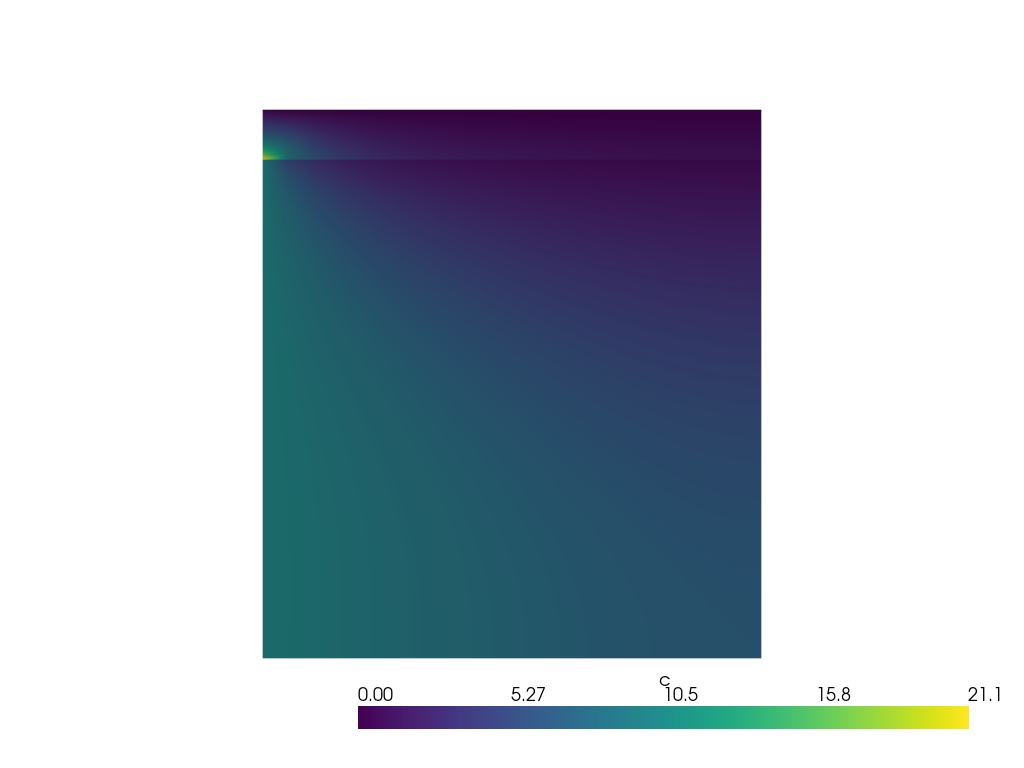

Flux:  30.45915192560526


In [15]:
from diffuser_simulator import make_festim_model
flux = make_festim_model(c_inlet=10, velocity_magnitude=10, run_post_processing=True)
print("Flux: ", flux)

## Generate some training data with the simulator

Here we generate 80 samples

In [2]:
n_samples = 80

X = simulator.sample_inputs(n_samples)

X.shape

torch.Size([80, 2])

In [3]:
Y, _ = simulator.forward_batch(X, allow_failures=False)
Y.shape

Running simulations: 100%|██████████| 80.0/80.0 [00:02<00:00, 27.6sample/s]


torch.Size([80])

In [4]:
Y

tensor([13.2630, 14.2159,  2.5689, 28.1715, 18.5997, 36.5047, 27.4088,  4.2922,
        31.5871, 34.8724, 29.8281,  5.3793,  4.4308, 47.7060, 21.3293, 31.9202,
        39.6239, 37.5122, 41.3667,  7.5605, 55.6211, 39.3087, 22.0641, 45.3707,
         1.8528, 11.5551, 47.1345, 17.7975, 29.3121, 61.8826, 48.7806,  5.2397,
        15.5703, 33.4726,  7.0995,  8.8367, 18.9995, 33.4776,  3.3709, 58.1533,
         6.7901, 13.0188,  1.3633, 44.6851, 16.7293, 41.1864, 15.1305, 36.7182,
        18.8967, 14.4071, 24.2854, 20.6631, 24.8593, 26.9866, 41.3112, 15.1766,
        31.4111, 43.4251, 41.4740, 46.0090, 47.8183, 25.1763, 11.2990, 34.4361,
        26.1287, 26.6139, 38.0093, 50.3707, 48.0023, 49.9090,  6.5001, 25.9182,
        55.0386, 16.7803,  0.2374, 17.3070, 37.4265, 47.5713, 10.6209,  8.9645])

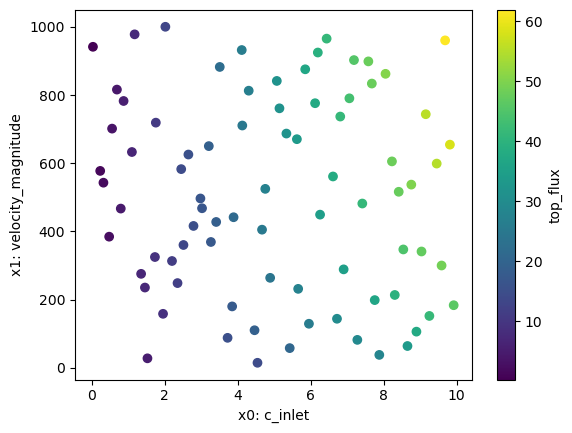

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis')
plt.colorbar(label='top_flux')
plt.show()

## Use the training data to train an Emulator

In [6]:
from autoemulate import AutoEmulate
# Run AutoEmulate with default settings
ae = AutoEmulate(X, Y, log_level="info")

INFO    2026-04-08 10:36:40,658 - autoemulate - Comparing ['GaussianProcessMatern32', 'GaussianProcessRBF', 'RadialBasisFunctions', 'PolynomialRegression', 'MLP', 'EnsembleMLP']
INFO    2026-04-08 10:36:40,658 - autoemulate - Running Model: GaussianProcessMatern32: 1/6 (attempt 1/3)
INFO    2026-04-08 10:37:06,170 - autoemulate - Finished running Model: GaussianProcessMatern32

INFO    2026-04-08 10:37:06,171 - autoemulate - Running Model: GaussianProcessRBF: 2/6 (attempt 1/3)
INFO    2026-04-08 10:37:20,786 - autoemulate - Finished running Model: GaussianProcessRBF

INFO    2026-04-08 10:37:20,787 - autoemulate - Running Model: RadialBasisFunctions: 3/6 (attempt 1/3)
INFO    2026-04-08 10:37:21,070 - autoemulate - Finished running Model: RadialBasisFunctions

INFO    2026-04-08 10:37:21,071 - autoemulate - Running Model: PolynomialRegression: 4/6 (attempt 1/3)
INFO    2026-04-08 10:37:35,222 - autoemulate - Finished running Model: PolynomialRegression

INFO    2026-04-08 10:37:35,223 

In [7]:
ae.summarise()

,model_name,x_transforms,y_transforms,params,r2_test,r2_test_std,rmse_test,rmse_test_std,r2_train,r2_train_std,rmse_train,rmse_train_std
2,RadialBasisFunctions,[StandardizeTransform()],[StandardizeTransform()],"{'kernel': 'quintic', 'degree': 2, 'smoothing'...",0.999538,0.000442,0.337434,0.171720,0.999930,0.000026,0.121708,0.020233
1,GaussianProcessRBF,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'lr': 0.1, 'likelihood_cls': <...",0.999360,0.000402,0.438049,0.103112,0.999956,0.000014,0.097532,0.012939
4,MLP,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'layer_dims': [32, 16], 'lr': ...",0.998722,0.000655,0.629889,0.117953,0.998688,0.000412,0.529703,0.065629
0,GaussianProcessMatern32,[StandardizeTransform()],[StandardizeTransform()],"{'epochs': 200, 'lr': 0.05, 'likelihood_cls': ...",0.998433,0.000576,0.723179,0.157921,0.999959,0.000020,0.093291,0.020091
3,PolynomialRegression,[StandardizeTransform()],[StandardizeTransform()],"{'lr': 0.1, 'epochs': 200, 'batch_size': 8, 's...",0.995131,0.002300,1.227031,0.210759,0.998221,0.000699,0.615417,0.112518
5,EnsembleMLP,[StandardizeTransform()],[StandardizeTransform()],"{'n_emulators': 2, 'epochs': 200, 'layer_dims'...",0.964582,0.008813,3.475215,0.528781,0.967195,0.003395,2.704738,0.262656


## Pick the GP model

In [8]:
# best = ae.best_result()
best = ae.results[0]
print("Model with id: ", best.id, " performed best: ", best.model_name)

Model with id:  0  performed best:  GaussianProcessMatern32


## Plot emulator performance

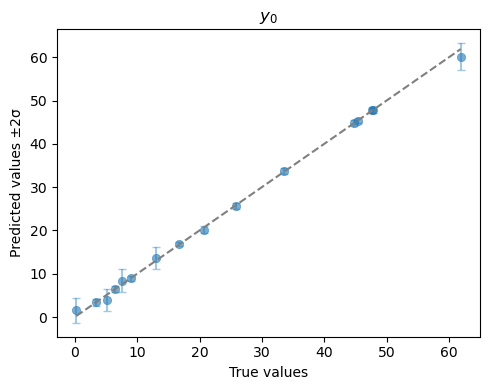

In [9]:
ae.plot_preds(best)

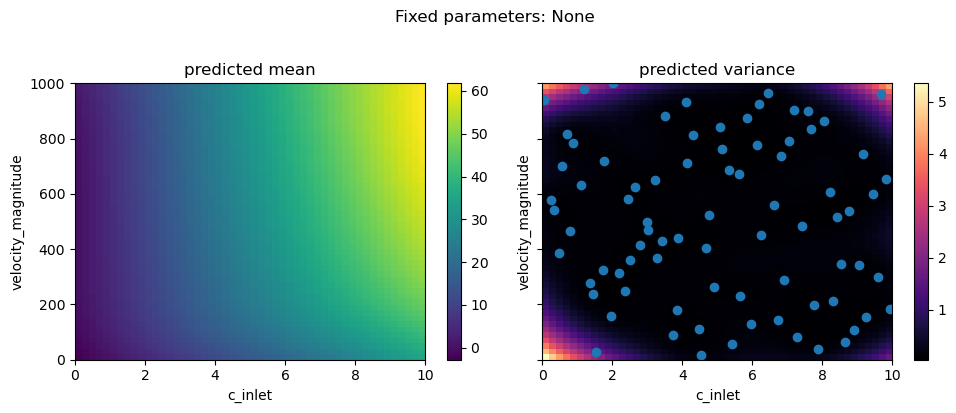

In [10]:
from autoemulate.core.plotting import create_and_plot_slice
fig, axs = create_and_plot_slice(best.model, parameters_range={"c_inlet": [0, 10],"velocity_magnitude": [0, 1000]}, quantile=0.5, param_pair=(0, 1))
plt.scatter(X[:, 0], X[:, 1])
plt.show()
